# 05 — Carry + Seasonality

VIX term-structure carry on SVXY and turn-of-month on SPY.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.backtest.runner import run
from src.data.store import get_or_fetch_panel


## VIX carry


In [2]:
from src.strategies.vix_carry import VixCarry

close = get_or_fetch_panel(['SVXY'], '2012-10-04')
strat = VixCarry(target='SVXY', smooth=5)
result = run(close, strat)
print(result.summary())


return=728.42% sharpe=0.70 mdd=-61.16% trades=31


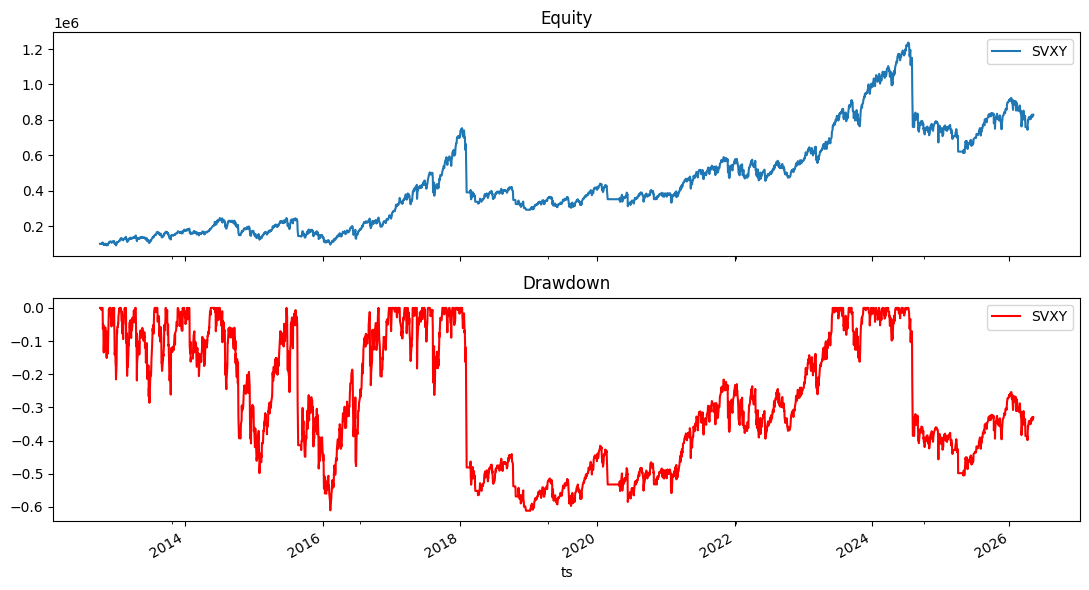

In [3]:
pf = result.portfolio
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
pf.value().plot(ax=axes[0]); axes[0].set_title('Equity')
pf.drawdown().plot(ax=axes[1], color='red'); axes[1].set_title('Drawdown')
plt.tight_layout(); plt.show()


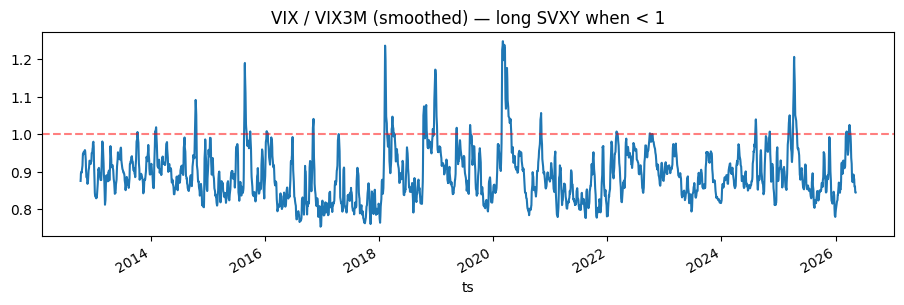

In [4]:
from src.data.store import get_or_fetch

ratio = strat._term_ratio(close.index)
fig, ax = plt.subplots(figsize=(11, 3))
ratio.plot(ax=ax)
ax.axhline(1.0, color='red', ls='--', alpha=0.5)
ax.set_title('VIX / VIX3M (smoothed) — long SVXY when < 1'); plt.show()


## Turn-of-month


In [5]:
from src.strategies.seasonality import TurnOfMonth

spy = get_or_fetch_panel(['SPY'], '2010-01-01')
strat_tom = TurnOfMonth(days_end=4, days_start=3)
result = run(spy, strat_tom)
print(result.summary())


return=74.12% sharpe=0.48 mdd=-23.54% trades=197


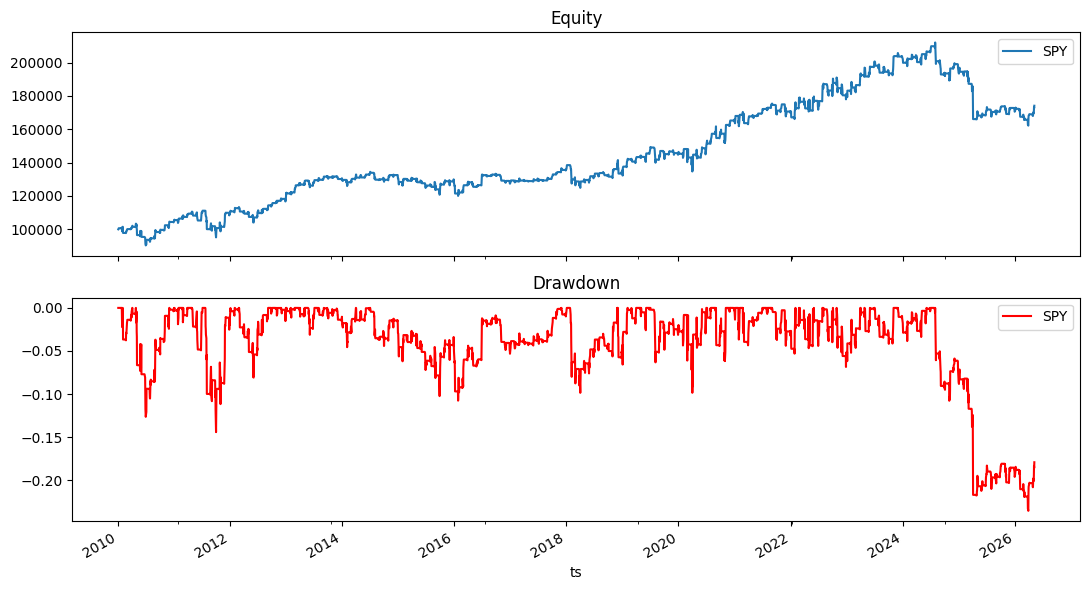

In [6]:
pf = result.portfolio
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
pf.value().plot(ax=axes[0]); axes[0].set_title('Equity')
pf.drawdown().plot(ax=axes[1], color='red'); axes[1].set_title('Drawdown')
plt.tight_layout(); plt.show()


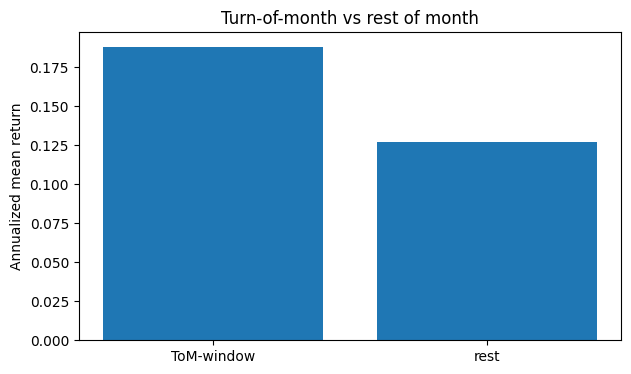

In [7]:
ret = spy['SPY'].pct_change()
mask = strat_tom.signals(spy)['SPY'].shift(1).fillna(False).astype(bool)
active = ret[mask]
inactive = ret[~mask]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['ToM-window', 'rest'], [active.mean()*252, inactive.mean()*252])
ax.set_ylabel('Annualized mean return'); ax.set_title('Turn-of-month vs rest of month'); plt.show()
